# Exploratory Data Analysis — Walmart Mexico Cash Demand

This notebook explores the raw transaction data and validates the statistical
assumptions that motivated the modeling choices:

1. Distribution of cash demand (justifies lognormal model)
2. Weekly seasonality (justifies day-of-week features)
3. Payday (quincena) effect (justifies `is_payday` feature)
4. Stationarity across stores
5. STL decomposition of a representative store


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from walmart_cash_forecast.data.loader import DataLoader
from walmart_cash_forecast.features.aggregator import StoreAggregator
from walmart_cash_forecast.features.imputer import CashImputer
from walmart_cash_forecast.stats.reporter import StatAnalyzer

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = Path('../data/raw')
REPORT_DIR = Path('../stats_report')
REPORT_DIR.mkdir(exist_ok=True)

In [2]:
transactions, stores, calendar = DataLoader(DATA_DIR).load()
print(f'Transactions: {transactions.shape}')
print(f'Stores: {stores.shape}')
transactions.head()

Transactions: (203958, 13)
Stores: (80, 9)


,date,store_id,category,total_transactions,cash_transactions,card_transactions,amount_total,amount_cash,amount_card,units_sold,avg_ticket,has_promotion,replenishment_signal
0,2023-01-01,STR_001,Abarrotes,833,NaN,326,244732.98,NaN,101822.79,2299.0,NaN,0,NaN
1,2023-01-02,STR_001,Abarrotes,1298,750.0,548,373235.09,222834.25,150400.84,3011.0,287.55,0,NaN
2,2023-01-03,STR_001,Abarrotes,1614,931.0,683,404249.92,239802.59,164447.33,3652.0,250.46,0,1546.00
3,2023-01-04,STR_001,Abarrotes,1726,972.0,754,423176.07,246810.92,176365.15,4165.0,245.18,0,1699.25
4,2023-01-05,STR_001,Abarrotes,2159,1028.0,675,458064.93,266559.26,191505.67,3553.0,268.98,1,1871.00


In [3]:
# Aggregate to store-day level (cashiers share one float per store)
panel = StoreAggregator().aggregate(transactions)
panel['day_of_week'] = panel['date'].dt.dayofweek
panel['is_payday'] = panel['date'].dt.day.isin([15]) | (
    panel['date'] == panel['date'].dt.to_period('M').dt.to_timestamp('M')
)
panel = CashImputer().fit(panel).transform(panel)
print(f'Panel shape: {panel.shape}, nulls: {panel["amount_cash"].isna().sum()}')
panel.head()

Panel shape: (33993, 12), nulls: 0


,store_id,date,cash_transactions,card_transactions,total_transactions,amount_cash,amount_card,amount_total,units_sold,has_promotion,day_of_week,is_payday
0,STR_001,2023-01-01,860.0,1568,2991,263548.21,557220.16,963678.56,6755.0,1,6,False
1,STR_001,2023-01-02,2087.0,2215,4505,666903.99,878865.44,1545769.43,9229.0,1,0,False
2,STR_001,2023-01-03,2276.0,2618,4894,651071.15,865799.78,1516870.93,10359.0,0,1,False
3,STR_001,2023-01-04,2402.0,2585,5242,670477.37,931704.89,1679867.13,9501.0,1,2,False
4,STR_001,2023-01-05,2596.0,2705,5986,801359.16,1044737.35,1846096.51,10737.0,1,3,False


## 1. Distribution of daily cash demand

We expect a right-skewed distribution — a log-normal is a natural choice for
positive-valued, multiplicatively driven quantities like retail cash demand.

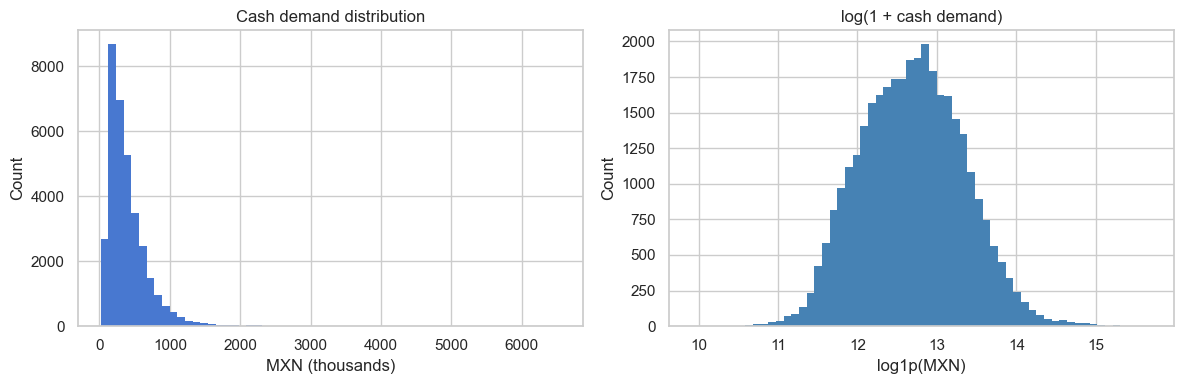

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(panel['amount_cash'] / 1_000, bins=60, edgecolor='none')
axes[0].set(title='Cash demand distribution', xlabel='MXN (thousands)', ylabel='Count')
axes[1].hist(np.log1p(panel['amount_cash']), bins=60, edgecolor='none', color='steelblue')
axes[1].set(title='log(1 + cash demand)', xlabel='log1p(MXN)', ylabel='Count')
plt.tight_layout()
plt.savefig('../stats_report/distribution.png', dpi=150)
plt.show()

## 2. Weekly seasonality

Retailers exhibit strong day-of-week effects. We expect weekends and paydays
to have higher demand.

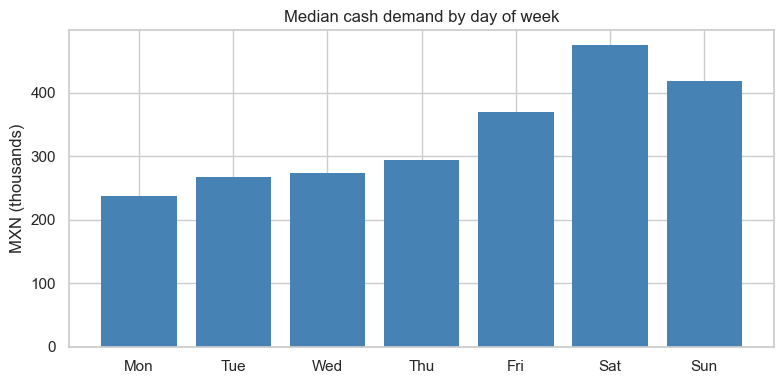

In [5]:
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_agg = panel.groupby('day_of_week')['amount_cash'].median() / 1_000
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_labels, dow_agg.values, color='steelblue', edgecolor='none')
ax.set(title='Median cash demand by day of week', ylabel='MXN (thousands)')
plt.tight_layout()
plt.savefig('../stats_report/day_of_week.png', dpi=150)
plt.show()

## 3. Payday (quincena) effect

Mexico's quincena paydays (day 15 and last day of month) should produce a
significant increase in cash demand.

Mann-Whitney U p-value: 0.0000
Effect size (relative median lift): 33.52%


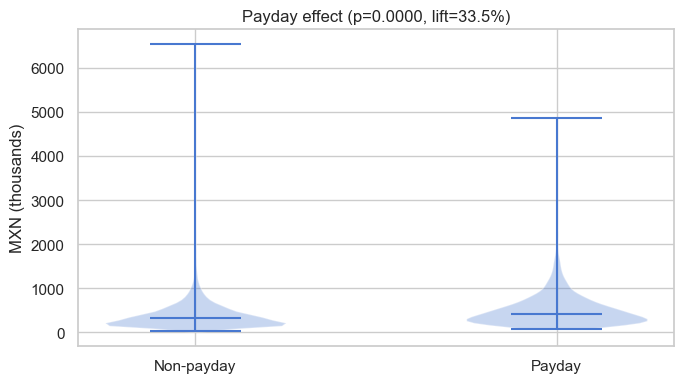

In [6]:
from scipy import stats

payday_cash = panel.loc[panel['is_payday'], 'amount_cash'].values
nonpayday_cash = panel.loc[~panel['is_payday'], 'amount_cash'].values

stat, pval = stats.mannwhitneyu(payday_cash, nonpayday_cash, alternative='greater')
effect_size = (np.median(payday_cash) - np.median(nonpayday_cash)) / np.median(nonpayday_cash)

print(f'Mann-Whitney U p-value: {pval:.4f}')
print(f'Effect size (relative median lift): {effect_size:.2%}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.violinplot([nonpayday_cash / 1_000, payday_cash / 1_000], positions=[0, 1], showmedians=True)
ax.set(xticks=[0, 1], xticklabels=['Non-payday', 'Payday'],
       ylabel='MXN (thousands)', title=f'Payday effect (p={pval:.4f}, lift={effect_size:.1%})')
plt.tight_layout()
plt.savefig('../stats_report/payday_effect.png', dpi=150)
plt.show()

## 4. Full statistical report

Run all four analyses (distribution, stationarity, STL, payday) and save JSON.

In [7]:
import json
report_dir = Path('../stats_report')
report_dir.mkdir(exist_ok=True)

# StatAnalyzer requires cash_transactions column; add it from transactions if available
if 'cash_transactions' not in panel.columns:
    tx_agg = transactions.groupby(['store_id', 'date'], as_index=False)['cash_transactions'].sum()
    panel = panel.merge(tx_agg, on=['store_id', 'date'], how='left')

report = StatAnalyzer().run(panel, report_dir)
print(json.dumps(report, indent=2, default=str))

{
  "distribution": {
    "best_model": "negbin",
    "aic_poisson": 22495565.33,
    "aic_negbin": 554065.08,
    "is_overdispersed": true,
    "negbin_alpha": 0.3904
  },
  "stationarity": {
    "pct_stores_stationary": 0.0,
    "per_store": {
      "STR_001": {
        "adf_pvalue": 0.0392,
        "kpss_pvalue": 0.01,
        "is_stationary": false
      },
      "STR_002": {
        "adf_pvalue": 0.036,
        "kpss_pvalue": 0.01,
        "is_stationary": false
      },
      "STR_003": {
        "adf_pvalue": 0.0553,
        "kpss_pvalue": 0.01,
        "is_stationary": false
      },
      "STR_004": {
        "adf_pvalue": 0.0516,
        "kpss_pvalue": 0.01,
        "is_stationary": false
      },
      "STR_005": {
        "adf_pvalue": 0.0499,
        "kpss_pvalue": 0.01,
        "is_stationary": false
      },
      "STR_006": {
        "adf_pvalue": 0.0047,
        "kpss_pvalue": 0.01,
        "is_stationary": false
      },
      "STR_007": {
        "adf_pvalue": 0.0508

## 5. STL decomposition

Seasonal-Trend via LOESS (period=7) on a representative store.

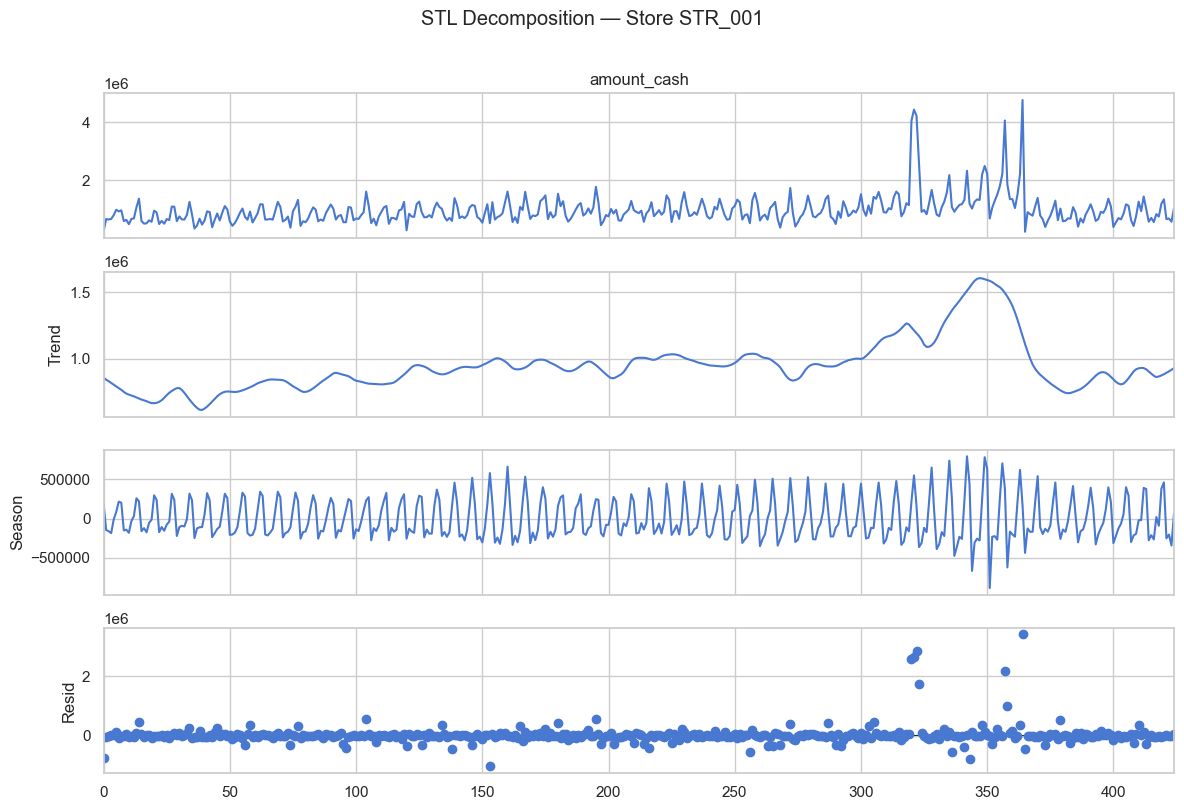

In [8]:
from statsmodels.tsa.seasonal import STL

store_id = panel['store_id'].iloc[0]
store_series = (
    panel[panel['store_id'] == store_id]
    .sort_values('date')['amount_cash']
    .reset_index(drop=True)
)

stl = STL(store_series, period=7, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f'STL Decomposition — Store {store_id}', y=1.01)
plt.tight_layout()
plt.savefig('../stats_report/stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()